# 📈 Análise Preditiva do Mercado Financeiro
## TCC — Ciência da Computação | Experimento de Classificação

---

**Objetivo:** Determinar o melhor algoritmo de classificação para prever se a ação **GOOG (Alphabet Inc.)** irá subir ou cair no pregão seguinte.

**Abordagem metodológica:**
1. Coleta de dados históricos via `yfinance`
2. Engenharia de features com indicadores técnicos (MA, RSI, MACD, Bollinger Bands)
3. Construção da variável-alvo binária com atenção ao *data leakage*
4. Pré-processamento e padronização
5. Treinamento comparativo de **10 modelos** em 4 paradigmas distintos
6. Validação temporal com `TimeSeriesSplit`
7. Avaliação e visualização dos resultados

> **⚠️ Nota Importante sobre Data Leakage em Séries Temporais:**
> Em problemas financeiros, o vazamento de dados é uma das armadilhas mais comuns e devastadoras.
> Utilizaremos exclusivamente validação temporal para garantir que o modelo nunca "veja o futuro" durante o treinamento.

---
## 0. Instalação e Importação de Dependências

Instalamos e importamos todas as bibliotecas necessárias para o experimento. Utilizamos:
- **`yfinance`**: coleta de dados históricos de mercado
- **`pandas` / `numpy`**: manipulação e computação numérica
- **`ta`**: biblioteca especializada em indicadores técnicos
- **`scikit-learn`**: modelos de ML, pré-processamento e métricas
- **`xgboost`**: implementação eficiente de Gradient Boosting
- **`lightgbm`**: Gradient Boosting leaf-wise da Microsoft
- **`catboost`**: Gradient Boosting com Ordered Boosting da Yandex
- **`matplotlib` / `seaborn`**: visualizações

In [1]:
# ─── Bibliotecas de dados e computação numérica ───
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Coleta de dados de mercado ───
import yfinance as yf

# ─── Indicadores técnicos ───
import ta
from ta.trend import MACD, SMAIndicator, EMAIndicator
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

# ─── Modelos de Machine Learning ───
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ─── Pré-processamento ───
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ─── Validação e métricas ───
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ─── Visualizações ───
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Configurações visuais ───
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14})

# ─── Semente aleatória para reprodutibilidade ───
RANDOM_STATE = 42

print("✅ Dependências importadas com sucesso!")

✅ Dependências importadas com sucesso!


---
## 1. Coleta de Dados Históricos

Utilizamos o `yfinance` para baixar os dados OHLCV (*Open, High, Low, Close, Volume*) do ticker **GOOG** referentes aos **últimos 5 anos**.

Os dados diários de mercado são a granularidade padrão para análise de swing trading e previsão de direção de preços a curto prazo.

In [2]:
def coletar_dados(ticker: str, periodo: str = '5y') -> pd.DataFrame:
    """
    Coleta dados históricos diários de um ticker via yfinance.

    Parâmetros:
        ticker  : símbolo do ativo (ex: 'GOOG')
        periodo : janela temporal (ex: '5y' = 5 anos)

    Retorna:
        DataFrame com colunas OHLCV indexado por data.
    """
    print(f"📡 Baixando dados de '{ticker}' — período: {periodo}...")
    
    # Faz o download via yfinance
    df = yf.download(ticker, period=periodo, interval='1d', progress=False, auto_adjust=True)
    
    # Achata o índice de colunas multinível (gerado pelo yfinance >= 0.2)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # Remove duplicatas e garante ordenação cronológica
    df = df[~df.index.duplicated(keep='first')].sort_index()
    
    print(f"✅ {len(df)} pregões coletados | {df.index.min().date()} → {df.index.max().date()}")
    return df


# ── Execução da coleta ──
df_raw = coletar_dados('GOOG', periodo='5y')

# Visualização inicial dos dados
print("\n📋 Primeiros registros:")
display(df_raw.head())
print("\n📊 Estatísticas descritivas:")
display(df_raw.describe().round(2))

📡 Baixando dados de 'GOOG' — período: 5y...
✅ 1256 pregões coletados | 2021-04-26 → 2026-04-24

📋 Primeiros registros:


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-04-26,115.389656,116.109750,114.749912,115.051929,20834000
2021-04-27,114.416641,115.920787,114.275300,115.848883,31972000
2021-04-28,118.026497,121.620389,117.775559,119.377156,59728000
2021-04-29,120.505157,120.833955,119.135898,119.535125,39554000
2021-04-30,119.524712,120.368787,119.129958,119.245510,39142000



📊 Estatísticas descritivas:


Price,Close,High,Low,Open,Volume
count,1256.00,1256.00,1256.00,1256.00,1256.00
mean,159.87,161.62,158.01,159.75,23932032.32
std,59.91,60.53,59.10,59.85,10167309.21
min,82.81,85.85,82.77,84.81,6138200.00
25%,121.75,122.43,120.31,121.12,17369625.00
50%,141.38,142.79,139.99,141.61,21519600.00
75%,175.26,177.22,173.44,175.09,27239975.00
max,344.66,349.90,338.35,348.27,97798600.00


---
## 2. Engenharia de Features — Indicadores Técnicos

Preços brutos isolados carregam pouca informação preditiva. Os **indicadores técnicos** são transformações matemáticas sobre os preços e o volume que capturam padrões de tendência, momentum e volatilidade — fundamentais para a análise do mercado.

Calcularemos:

| Indicador | Tipo | O que mede |
|---|---|---|
| **SMA 10/20** | Tendência | Média dos últimos N fechamentos |
| **EMA 12/26** | Tendência | Média ponderada exponencialmente |
| **MACD** | Momentum/Tendência | Diferença entre EMAs; detecta reversões |
| **RSI (14)** | Momentum | Velocidade e magnitude das variações de preço (0-100) |
| **Bollinger Bands** | Volatilidade | Canais de desvio padrão ao redor da média |
| **Volume Change** | Volume | Variação percentual do volume negociado |
| **Daily Return** | Retorno | Retorno percentual diário do preço de fechamento |

> **⚠️ Cuidado com o Data Leakage:** Todos os indicadores são calculados usando **apenas dados passados** em relação a cada dia. Isso é garantido pela própria matemática dos indicadores (janelas deslizantes retrospectivas).

In [3]:
def calcular_indicadores_tecnicos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adiciona indicadores técnicos ao DataFrame de preços OHLCV.

    Todos os indicadores utilizam APENAS informações passadas (sem look-ahead bias).

    Parâmetros:
        df : DataFrame com colunas Open, High, Low, Close, Volume

    Retorna:
        DataFrame enriquecido com as features de indicadores técnicos.
    """
    # Cria uma cópia para não modificar o DataFrame original
    data = df.copy()

    # ── Preços de fechamento e volume como Series ──
    close = data['Close']
    high  = data['High']
    low   = data['Low']
    vol   = data['Volume']

    # ── 1. Médias Móveis Simples (SMA) ──
    # Capturam a tendência de médio/longo prazo
    data['SMA_10'] = SMAIndicator(close=close, window=10).sma_indicator()
    data['SMA_20'] = SMAIndicator(close=close, window=20).sma_indicator()

    # ── 2. Médias Móveis Exponenciais (EMA) ──
    # Dão mais peso aos dados recentes — mais reativas que as SMAs
    data['EMA_12'] = EMAIndicator(close=close, window=12).ema_indicator()
    data['EMA_26'] = EMAIndicator(close=close, window=26).ema_indicator()

    # ── 3. MACD (Moving Average Convergence Divergence) ──
    # Sinal clássico de compra/venda: cruzamento entre MACD e Signal Line
    macd_indicator = MACD(close=close, window_slow=26, window_fast=12, window_sign=9)
    data['MACD']        = macd_indicator.macd()             # Linha MACD
    data['MACD_Signal'] = macd_indicator.macd_signal()      # Linha de sinal
    data['MACD_Hist']   = macd_indicator.macd_diff()        # Histograma (MACD - Signal)

    # ── 4. RSI (Relative Strength Index) ──
    # Oscila entre 0 e 100: >70 = sobrecomprado; <30 = sobrevendido
    data['RSI_14'] = RSIIndicator(close=close, window=14).rsi()

    # ── 5. Bandas de Bollinger ──
    # Medem volatilidade: quando o preço toca a banda, pode indicar reversão
    bb = BollingerBands(close=close, window=20, window_dev=2)
    data['BB_High']  = bb.bollinger_hband()   # Banda superior (média + 2σ)
    data['BB_Low']   = bb.bollinger_lband()   # Banda inferior (média − 2σ)
    data['BB_Width'] = bb.bollinger_wband()   # Largura das bandas (proxy de volatilidade)
    data['BB_Pct']   = bb.bollinger_pband()   # Posição do preço dentro das bandas [0,1]

    # ── 6. Variação Percentual do Volume ──
    # Volume acima do normal geralmente confirma movimentos de preço
    data['Volume_Change'] = vol.pct_change()

    # ── 7. Retorno Diário (Daily Return) ──
    # Variação percentual do preço de fechamento em relação ao dia anterior
    data['Daily_Return'] = close.pct_change()

    # ── 8. Features de distância entre preço e médias ──
    # Normalizam a posição do preço em relação às tendências
    data['Price_to_SMA20'] = (close - data['SMA_20']) / data['SMA_20']
    data['Price_to_EMA26'] = (close - data['EMA_26']) / data['EMA_26']

    print(f"✅ Indicadores calculados. Colunas no dataset: {list(data.columns)}")
    return data


# ── Execução do cálculo de indicadores ──
df_features = calcular_indicadores_tecnicos(df_raw)

print(f"\n📐 Shape do dataset: {df_features.shape}")

✅ Indicadores calculados. Colunas no dataset: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI_14', 'BB_High', 'BB_Low', 'BB_Width', 'BB_Pct', 'Volume_Change', 'Daily_Return', 'Price_to_SMA20', 'Price_to_EMA26']

📐 Shape do dataset: (1256, 21)


---
## 3. Construção da Variável-Alvo (Target)

A **variável-alvo binária** é definida como:

$$
\text{target}_t =
\begin{cases}
1 & \text{se } \text{Close}_{t+1} > \text{Close}_t \\
0 & \text{caso contrário}
\end{cases}
$$

**Implementação com `.shift(-1)`:** Para criar o target do "dia seguinte", deslocamos a coluna `Close` em **−1 posição** (para frente no tempo). Isso significa que, para cada linha $t$, o target contém o preço de fechamento do dia $t+1$.

> **⚠️ Armadilha crítica — Data Leakage:** O shift deve ser aplicado **apenas** na coluna de fechamento para construir o target. As features de cada linha $t$ devem conter **apenas** dados disponíveis **até** o final do pregão $t$ — nunca informações de $t+1$. O `.dropna()` ao final remove a última linha (que não terá target válido após o shift).

🎯 Distribuição da variável-alvo:
   Classe 0 (Queda/Estável): 568 dias (46.4%)
   Classe 1 (Alta):          655 dias (53.6%)


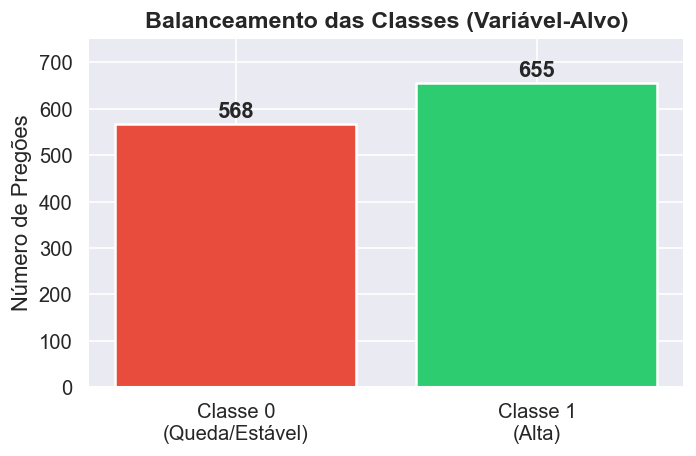


📐 Shape final do dataset: (1223, 22)


In [4]:
def criar_variavel_alvo(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria a variável-alvo binária de previsão de direção do preço.

    Lógica:
        - Se o preço de fechamento de AMANHÃ > fechamento de HOJE → Target = 1 (alta)
        - Caso contrário → Target = 0 (queda ou estabilidade)

    O .shift(-1) desloca o Close uma posição para trás no índice temporal,
    efetivamente associando a cada linha o fechamento do dia SEGUINTE.
    """
    data = df.copy()

    # Preço de fechamento do DIA SEGUINTE (via shift(-1))
    close_amanha = data['Close'].shift(-1)

    # Cria o target: 1 se amanhã > hoje, 0 caso contrário
    data['Target'] = (close_amanha > data['Close']).astype(int)

    # Remove a última linha — ela não tem target válido (close_amanha = NaN)
    data.dropna(inplace=True)

    return data


# ── Criação do target ──
df_model = criar_variavel_alvo(df_features)

# ── Análise do balanceamento das classes ──
contagem = df_model['Target'].value_counts()
proporcao = df_model['Target'].value_counts(normalize=True) * 100

print("🎯 Distribuição da variável-alvo:")
print(f"   Classe 0 (Queda/Estável): {contagem[0]} dias ({proporcao[0]:.1f}%)")
print(f"   Classe 1 (Alta):          {contagem[1]} dias ({proporcao[1]:.1f}%)")

# Visualização do balanceamento
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Classe 0\n(Queda/Estável)', 'Classe 1\n(Alta)'],
              [contagem[0], contagem[1]],
              color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Balanceamento das Classes (Variável-Alvo)', fontweight='bold')
ax.set_ylabel('Número de Pregões')
ax.set_ylim(0, max(contagem) * 1.15)
plt.tight_layout()
plt.savefig('balanceamento_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📐 Shape final do dataset: {df_model.shape}")

---
## 4. Pré-processamento: Separação de Features e Padronização

### 4.1 Separação de Features (X) e Target (y)

Removemos as colunas de preço bruto (**OHLCV**) do conjunto de features, pois utilizaremos **apenas os indicadores técnicos derivados**. Incluir o preço bruto junto com indicadores derivados dele pode causar multicolinearidade.

### 4.2 Padronização com StandardScaler

A **padronização** (z-score normalization) transforma cada feature para ter **média 0 e desvio padrão 1**:

$$z = \frac{x - \mu}{\sigma}$$

Isso é **essencial** para modelos baseados em gradiente (Regressão Logística) e **melhora a convergência** de outros algoritmos. O Random Forest e XGBoost são invariantes à escala, mas a padronização não os prejudica.

> **Importante:** O `StandardScaler` será encapsulado dentro de um `Pipeline` do scikit-learn, garantindo que o scaler seja **treinado apenas nos dados de treino** de cada fold do `TimeSeriesSplit`, evitando vazamento de estatísticas dos dados de teste.

In [5]:
def preparar_features_target(df: pd.DataFrame):
    """
    Separa o DataFrame em features (X) e target (y).

    Colunas removidas de X:
        - Preços brutos OHLCV originais (Open, High, Low, Close, Volume)
        - A própria coluna 'Target'

    Retorna:
        X : DataFrame de features (indicadores técnicos)
        y : Series com a variável-alvo binária
    """
    # Colunas originais de preço que NÃO serão usadas como features
    colunas_remover = ['Open', 'High', 'Low', 'Close', 'Volume', 'Target']

    # Features: todos os indicadores técnicos calculados
    X = df.drop(columns=colunas_remover)

    # Target: variável binária de direção
    y = df['Target']

    print(f"📌 Features selecionadas ({X.shape[1]}): {list(X.columns)}")
    print(f"📌 Amostras totais: {X.shape[0]}")
    print(f"📌 NaN remanescentes em X: {X.isna().sum().sum()}")

    return X, y


# ── Separação de X e y ──
X, y = preparar_features_target(df_model)

# Verifica ausência de NaN (essencial antes do treinamento)
assert X.isna().sum().sum() == 0, "❌ Ainda existem NaN nas features!"
print("\n✅ Nenhum valor NaN detectado — dataset pronto para modelagem.")

📌 Features selecionadas (16): ['SMA_10', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI_14', 'BB_High', 'BB_Low', 'BB_Width', 'BB_Pct', 'Volume_Change', 'Daily_Return', 'Price_to_SMA20', 'Price_to_EMA26']
📌 Amostras totais: 1223
📌 NaN remanescentes em X: 0

✅ Nenhum valor NaN detectado — dataset pronto para modelagem.


---
## 5. Definição dos Modelos e Validação Temporal

### 5.1 Por que TimeSeriesSplit e não K-Fold?

O **K-Fold tradicional** embaralha os dados antes de criar as folds, o que em séries temporais gera um problema gravíssimo: o modelo pode ser treinado com dados do **futuro** para prever o **passado**. Isso viola a causalidade e produz métricas irrealisticamente otimistas.

O **`TimeSeriesSplit`** garante que:
- Os dados de **treino** estejam sempre **antes** dos dados de **teste** no eixo temporal
- A cada fold, o conjunto de treino cresce progressivamente
- O modelo nunca "vê" o futuro durante o treinamento

```
Fold 1: [===TREINO===] [TESTE]
Fold 2: [=====TREINO=====] [TESTE]
Fold 3: [=======TREINO=======] [TESTE]
Fold 4: [=========TREINO=========] [TESTE]
Fold 5: [===========TREINO===========] [TESTE]
```

### 5.2 Espaço de Hipóteses — Modelos Avaliados

Cobrimos **4 paradigmas distintos** de aprendizado de máquina, maximizando a diversidade de vieses indutivos e a chance de encontrar o melhor fit para os dados:

| Paradigma | Modelo | Razão para incluir |
|---|---|---|
| **Linear** | Logistic Regression | Baseline interpretável; regularização L2 |
| **Kernel** | SVM (RBF) | Excelente em espaços de alta dimensão; margem máxima |
| **Bagging** | Random Forest | Robusto, baixa variância, resistente a overfitting |
| **Bagging** | Extra Trees | Mais aleatório que RF; menor variância, maior bias |
| **Boosting** | Gradient Boosting | Boosting clássico sklearn; menor risco de overfit que XGB |
| **Boosting** | XGBoost | GBDT otimizado; regularização L1/L2 nativa |
| **Boosting** | LightGBM | Leaf-wise growth; mais rápido e preciso em datasets grandes |
| **Boosting** | CatBoost | Ordered boosting; reduz target leakage durante o treino |
| **Meta-Ensemble** | Voting (Soft) | Agrega probabilidades dos 3 melhores boosters |
| **Meta-Ensemble** | Stacking | Meta-modelo aprende a combinar as previsões base |

In [6]:
def definir_modelos() -> dict:
    """
    Define os Pipelines de modelagem para cada algoritmo.

    Arquitetura de cada Pipeline:
        1. StandardScaler : padroniza features (fitado apenas no fold de treino)
        2. Classificador  : o algoritmo de ML propriamente dito

    A escolha de 10 modelos de 4 paradigmas distintos maximiza a cobertura
    do espaço de hipóteses, aumentando a chance de encontrar o melhor fit
    para a estrutura não-linear da série temporal financeira.
    """

    # ══════════════════════════════════════════════════════════════════
    # ── PARADIGMA 1: MODELO LINEAR ────────────────────────────────────
    # ══════════════════════════════════════════════════════════════════

    # Regressão Logística — baseline interpretável
    # Útil para entender se há sinal linear nos indicadores;
    # regularização L2 (C=0.1) penaliza coeficientes grandes.
    logistic = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1,
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ])

    # ══════════════════════════════════════════════════════════════════
    # ── PARADIGMA 2: KERNEL (SVM) ─────────────────────────────────────
    # ══════════════════════════════════════════════════════════════════

    # SVM com kernel RBF (Radial Basis Function)
    # Mapeia implicitamente os dados para um espaço de alta dimensão e
    # encontra o hiperplano de margem máxima. Excelente para capturar
    # fronteiras de decisão não-lineares suaves — comum em séries financeiras.
    # probability=True habilita predição de probabilidade (necessário para o Voting Soft).
    svm_rbf = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',          # gamma = 1 / (n_features * X.var())
            probability=True,       # habilita predict_proba
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ])

    # ══════════════════════════════════════════════════════════════════
    # ── PARADIGMA 3: BAGGING (Florestas Aleatórias) ───────────────────
    # ══════════════════════════════════════════════════════════════════

    # Random Forest — ensemble de árvores com bootstrap + feature sampling
    # Reduz variância via bagging. max_depth=6 e min_samples_leaf=10
    # evitam overfitting na série temporal ruidosa.
    random_forest = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=10,
            max_features='sqrt',    # amostra √n features por split
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    # Extra Trees (Extremely Randomized Trees)
    # Similar ao RF, mas os thresholds dos splits são gerados ALEATORIAMENTE
    # em vez de otimizados. Isso reduz ainda mais a variância ao custo de
    # um bias ligeiramente maior. Frequentemente supera RF em dados ruidosos.
    extra_trees = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', ExtraTreesClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=10,
            max_features='sqrt',
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    # ══════════════════════════════════════════════════════════════════
    # ── PARADIGMA 4: BOOSTING (Ensemble Sequencial) ───────────────────
    # ══════════════════════════════════════════════════════════════════

    # Gradient Boosting (sklearn) — implementação clássica GBDT
    # Treina árvores sequencialmente para corrigir os erros residuais.
    # subsample<1.0 introduz estocasticidade (Stochastic GB), reduzindo overfitting.
    grad_boost = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,          # fração das amostras por árvore
            min_samples_leaf=10,
            random_state=RANDOM_STATE
        ))
    ])

    # XGBoost — GBDT altamente otimizado com regularização L1/L2 nativa
    # O parâmetro reg_alpha (L1) e reg_lambda (L2) previnem overfitting.
    # colsample_bytree=0.8 amostra 80% das features por árvore.
    xgboost = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,          # regularização L1 (Lasso)
            reg_lambda=1.0,         # regularização L2 (Ridge)
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        ))
    ])

    # LightGBM — Gradient Boosting com crescimento leaf-wise (em vez de level-wise)
    # Leaf-wise cresce a folha com maior ganho de impureza, convergindo mais rápido.
    # Muito eficiente em memória e tempo; frequentemente supera XGBoost em datasets
    # com muitas features. num_leaves controla a complexidade do modelo.
    lightgbm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LGBMClassifier(
            n_estimators=300,
            num_leaves=31,          # controla complexidade (2^max_depth recomendado)
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1              # suprime logs de treinamento
        ))
    ])

    # CatBoost — Gradient Boosting com 'Ordered Boosting'
    # Técnica proprietária da Yandex que embaralha aleatoriamente as amostras
    # e calcula os resíduos de forma ordenada, eliminando target leakage durante
    # o treino. Isso torna o CatBoost intrinsecamente mais robusto a overfitting.
    # iterations equivale a n_estimators.
    catboost = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.05,
            l2_leaf_reg=3.0,        # regularização L2 das folhas
            subsample=0.8,
            random_state=RANDOM_STATE,
            verbose=False,          # suprime logs de treinamento
            auto_class_weights='Balanced'
        ))
    ])

    # ══════════════════════════════════════════════════════════════════
    # ── PARADIGMA 5: META-ENSEMBLES ───────────────────────────────────
    # ══════════════════════════════════════════════════════════════════

    # Voting Classifier (Soft Voting) — combina XGBoost, LightGBM e CatBoost
    # O soft voting agrega as PROBABILIDADES previstas por cada estimador
    # (em vez de votos majoritários), aproveitando melhor a calibração de
    # cada modelo. Os três boosters são escolhidos por compartilharem o
    # mesmo paradigma mas divergirem em algoritmo interno, gerando
    # diversidade de predição sem correlação excessiva.
    voting_soft = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', VotingClassifier(
            estimators=[
                ('xgb', XGBClassifier(
                    n_estimators=200, max_depth=4, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric='logloss', random_state=RANDOM_STATE,
                    verbosity=0, n_jobs=-1
                )),
                ('lgbm', LGBMClassifier(
                    n_estimators=200, num_leaves=31, learning_rate=0.05,
                    subsample=0.8, class_weight='balanced',
                    random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
                )),
                ('cat', CatBoostClassifier(
                    iterations=200, depth=4, learning_rate=0.05,
                    random_state=RANDOM_STATE, verbose=False,
                    auto_class_weights='Balanced'
                ))
            ],
            voting='soft',          # usa probabilidades
            n_jobs=-1
        ))
    ])

    # Stacking Classifier — meta-aprendizado em dois níveis
    # Nível 0 (estimadores base): modelos de paradigmas diferentes geram
    #   predições out-of-fold (sem data leakage interno).
    # Nível 1 (meta-modelo): a Regressão Logística aprende a combinar
    #   as predições dos modelos base de forma ótima.
    # cv=TimeSeriesSplit(5) na base garante validação temporal também
    # nas predições out-of-fold — detalhe crítico para séries financeiras.
    stacking = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', StackingClassifier(
            estimators=[
                ('rf',   RandomForestClassifier(
                    n_estimators=200, max_depth=5, class_weight='balanced',
                    random_state=RANDOM_STATE, n_jobs=-1
                )),
                ('xgb',  XGBClassifier(
                    n_estimators=200, max_depth=4, learning_rate=0.05,
                    eval_metric='logloss', random_state=RANDOM_STATE,
                    verbosity=0, n_jobs=-1
                )),
                ('lgbm', LGBMClassifier(
                    n_estimators=200, num_leaves=31, learning_rate=0.05,
                    class_weight='balanced', random_state=RANDOM_STATE,
                    verbose=-1, n_jobs=-1
                )),
                ('cat',  CatBoostClassifier(
                    iterations=200, depth=4, learning_rate=0.05,
                    random_state=RANDOM_STATE, verbose=False,
                    auto_class_weights='Balanced'
                ))
            ],
            # Meta-modelo leve: aprende a ponderar os estimadores base
            final_estimator=LogisticRegression(
                C=0.1, max_iter=1000,
                class_weight='balanced',
                random_state=RANDOM_STATE
            ),
            # Validação temporal das predições out-of-fold dos estimadores base
            cv=TimeSeriesSplit(n_splits=5),
            stack_method='predict_proba',  # usa probabilidades como meta-features
            passthrough=False,
            n_jobs=-1
        ))
    ])

    # ── Dicionário final de modelos ──
    modelos = {
        # Paradigma Linear
        'Logistic Regression' : logistic,
        # Paradigma Kernel
        'SVM (RBF)'           : svm_rbf,
        # Paradigma Bagging
        'Random Forest'       : random_forest,
        'Extra Trees'         : extra_trees,
        # Paradigma Boosting
        'Gradient Boosting'   : grad_boost,
        'XGBoost'             : xgboost,
        'LightGBM'            : lightgbm,
        'CatBoost'            : catboost,
        # Meta-Ensembles
        'Voting (Soft)'       : voting_soft,
        'Stacking'            : stacking,
    }
    return modelos


# ── Instanciação dos modelos ──
modelos = definir_modelos()

print("✅ Modelos e Pipelines definidos — espaço de hipóteses completo:")
paradigmas = {
    'Linear'        : ['Logistic Regression'],
    'Kernel'        : ['SVM (RBF)'],
    'Bagging'       : ['Random Forest', 'Extra Trees'],
    'Boosting'      : ['Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Meta-Ensemble' : ['Voting (Soft)', 'Stacking'],
}
for paradigma, nomes in paradigmas.items():
    print(f"\n  [{paradigma}]")
    for nome in nomes:
        print(f"    • {nome}")
print(f"\n📦 Total: {len(modelos)} modelos")

✅ Modelos e Pipelines definidos — espaço de hipóteses completo:

  [Linear]
    • Logistic Regression

  [Kernel]
    • SVM (RBF)

  [Bagging]
    • Random Forest
    • Extra Trees

  [Boosting]
    • Gradient Boosting
    • XGBoost
    • LightGBM
    • CatBoost

  [Meta-Ensemble]
    • Voting (Soft)
    • Stacking

📦 Total: 10 modelos


---
## 6. Treinamento e Avaliação com Validação Cruzada Temporal

Utilizamos `cross_validate` do scikit-learn com o `TimeSeriesSplit` (5 folds) para obter estimativas robustas do desempenho de cada modelo.

As métricas coletadas são:
- **Acurácia:** proporção de previsões corretas (pode ser enganosa em classes desbalanceadas)
- **Precision:** dos dias previstos como alta, quantos realmente foram alta
- **Recall:** dos dias que realmente foram alta, quantos o modelo identificou
- **F1-Score:** média harmônica entre Precision e Recall — a métrica mais balanceada para este problema

In [7]:
def executar_validacao_cruzada_temporal(modelos: dict, X: pd.DataFrame, y: pd.Series,
                                        n_splits: int = 5) -> pd.DataFrame:
    """
    Executa validação cruzada temporal para todos os modelos.

    Parâmetros:
        modelos  : dicionário {nome: pipeline}
        X        : DataFrame de features
        y        : Series de target
        n_splits : número de folds do TimeSeriesSplit

    Retorna:
        DataFrame com as métricas médias e desvio padrão para cada modelo.
    """
    # Validação temporal: nunca usa dados futuros no treino
    tscv = TimeSeriesSplit(n_splits=n_splits)

    # Métricas a serem calculadas em cada fold
    metricas_scoring = {
        'accuracy':  'accuracy',
        'precision': 'precision',
        'recall':    'recall',
        'f1':        'f1'
    }

    resultados = []

    print(f"🔄 Iniciando validação cruzada temporal ({n_splits} folds)...\n")
    print("-" * 65)

    for nome, pipeline in modelos.items():
        print(f"⚙️  Treinando: {nome}")

        # Executa a validação cruzada em todos os folds
        cv_result = cross_validate(
            estimator=pipeline,
            X=X,
            y=y,
            cv=tscv,
            scoring=metricas_scoring,
            return_train_score=False,
            n_jobs=-1
        )

        # Agrega os resultados (média ± desvio padrão dos folds)
        resultado_modelo = {'Modelo': nome}
        for metrica in metricas_scoring:
            scores = cv_result[f'test_{metrica}']
            resultado_modelo[f'{metrica.capitalize()}_Mean'] = scores.mean()
            resultado_modelo[f'{metrica.capitalize()}_Std']  = scores.std()
            print(f"      {metrica.capitalize():10s}: {scores.mean():.4f} ± {scores.std():.4f}")

        resultados.append(resultado_modelo)
        print()

    print("-" * 65)
    print("✅ Validação cruzada concluída!")

    return pd.DataFrame(resultados).set_index('Modelo')


# ── Execução da validação cruzada ──
df_resultados = executar_validacao_cruzada_temporal(modelos, X, y, n_splits=5)

print("\n📊 Tabela de Resultados — Médias das Métricas:")
display(df_resultados.round(4))

🔄 Iniciando validação cruzada temporal (5 folds)...

-----------------------------------------------------------------
⚙️  Treinando: Logistic Regression
      Accuracy  : 0.5054 ± 0.0361
      Precision : 0.5315 ± 0.0494
      Recall    : 0.6646 ± 0.2310
      F1        : 0.5693 ± 0.1027

⚙️  Treinando: SVM (RBF)
      Accuracy  : 0.4897 ± 0.0293
      Precision : 0.5764 ± 0.1233
      Recall    : 0.3035 ± 0.2346
      F1        : 0.3332 ± 0.1952

⚙️  Treinando: Random Forest
      Accuracy  : 0.4828 ± 0.0351
      Precision : 0.5287 ± 0.0345
      Recall    : 0.4581 ± 0.2567
      F1        : 0.4435 ± 0.1533

⚙️  Treinando: Extra Trees
      Accuracy  : 0.4906 ± 0.0369
      Precision : 0.5665 ± 0.0849
      Recall    : 0.4999 ± 0.3439
      F1        : 0.4420 ± 0.2007

⚙️  Treinando: Gradient Boosting
      Accuracy  : 0.4729 ± 0.0352
      Precision : 0.5163 ± 0.0354
      Recall    : 0.4128 ± 0.2377
      F1        : 0.4143 ± 0.1514

⚙️  Treinando: XGBoost
      Accuracy  : 0.4749

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Projects\TCC-NeuroFinance\neuro-learning\venv\Lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Projects\TCC-NeuroFinance\neuro-learning\venv\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Projects\TCC-NeuroFinance\neuro-learning\venv\Lib\site-packages\sklearn\utils\parallel.py", line 184, in __call__
    return self.function(*args, **kwargs)
           ^^^^^^^

---
## 7. Visualização dos Resultados

### 7.1 Gráfico Comparativo de F1-Score

O **F1-Score** é a métrica principal de comparação pois pondera igualmente Precision e Recall, sendo mais informativa que a acurácia simples — especialmente quando as classes não são perfeitamente balanceadas.

In [ ]:
def plotar_comparacao_metricas(df_resultados: pd.DataFrame):
    """
    Plota um gráfico de barras comparando todas as métricas dos modelos,
    com barras de erro representando o desvio padrão entre os folds.
    """
    metricas = ['Accuracy', 'Precision', 'Recall', 'F1']
    modelos_nomes = df_resultados.index.tolist()
    cores = ['#3498db', '#e74c3c', '#2ecc71']

    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
    fig.suptitle('Comparação de Métricas — Validação Cruzada Temporal (5 Folds)',
                 fontsize=15, fontweight='bold', y=1.02)

    for ax, metrica in zip(axes, metricas):
        means = df_resultados[f'{metrica}_Mean'].values
        stds  = df_resultados[f'{metrica}_Std'].values

        bars = ax.bar(modelos_nomes, means, yerr=stds, capsize=5,
                      color=cores, edgecolor='white', linewidth=1.2,
                      error_kw={'elinewidth': 1.5, 'ecolor': 'gray', 'alpha': 0.7})

        # Anotação com o valor numérico em cada barra
        for bar, mean_val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{mean_val:.3f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.set_title(metrica, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(modelos_nomes)))
        ax.set_xticklabels([m.replace(' ', '\n') for m in modelos_nomes],
                           fontsize=9)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.3, linewidth=1)

    axes[0].set_ylabel('Score', fontweight='bold')
    plt.tight_layout()
    plt.savefig('comparacao_metricas.png', dpi=150, bbox_inches='tight')
    plt.show()


plotar_comparacao_metricas(df_resultados)

### 7.2 Gráfico de Barras — F1-Score (Destaque)

Visualização isolada do **F1-Score** com destaque para o melhor modelo.

In [ ]:
def plotar_f1_score_comparativo(df_resultados: pd.DataFrame):
    """
    Plota gráfico de barras horizontal do F1-Score com destaque no melhor modelo.
    """
    # Identifica o melhor modelo pelo F1-Score médio
    melhor_modelo = df_resultados['F1_Mean'].idxmax()
    f1_scores     = df_resultados['F1_Mean']
    f1_stds       = df_resultados['F1_Std']

    # Define cores: destaque dourado para o melhor, cinza para os demais
    cores = ['#f39c12' if m == melhor_modelo else '#bdc3c7'
             for m in f1_scores.index]

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.barh(f1_scores.index, f1_scores.values,
                   xerr=f1_stds.values, capsize=4,
                   color=cores, edgecolor='white', linewidth=1.5,
                   error_kw={'elinewidth': 2, 'ecolor': '#7f8c8d'})

    # Anotações com os valores
    for i, (bar, val, std) in enumerate(zip(bars, f1_scores.values, f1_stds.values)):
        ax.text(val + std + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f} ± {std:.4f}',
                va='center', fontsize=11, fontweight='bold')

    # Linha de referência em 0.5 (classificador aleatório)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5,
               label='Baseline (aleatório = 0.5)')

    ax.set_xlabel('F1-Score (Média dos Folds Temporais)', fontweight='bold', fontsize=12)
    ax.set_title(f'🏆 Comparação de F1-Score — Melhor: {melhor_modelo}',
                 fontweight='bold', fontsize=14)
    ax.set_xlim(0, 1.0)
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    plt.tight_layout()
    plt.savefig('f1_score_comparativo.png', dpi=150, bbox_inches='tight')
    plt.show()

    return melhor_modelo


melhor_modelo_nome = plotar_f1_score_comparativo(df_resultados)
print(f"\n🏆 Melhor modelo pelo F1-Score médio: {melhor_modelo_nome}")

---
## 8. Análise Detalhada do Melhor Modelo

Treinamos o melhor modelo no conjunto de dados completo (exceto os últimos 20% reservados como holdout temporal) e avaliamos na porção final da série temporal — simulando uma situação real de uso do modelo no mercado.

### Por que usar holdout temporal e não apenas o cross-validate?

O `cross_validate` nos dá uma estimativa robusta do desempenho, mas para a **avaliação final e relatório**, é boa prática treinar no máximo de dados históricos e avaliar em um período recente **nunca visto** pelo modelo — simulando a implantação real.

In [ ]:
def avaliar_melhor_modelo(nome_modelo: str, modelos: dict,
                          X: pd.DataFrame, y: pd.Series,
                          proporcao_teste: float = 0.2):
    """
    Treina e avalia o melhor modelo em um holdout temporal (últimos X% dos dados).

    A divisão é TEMPORAL (cronológica) — nunca aleatória.

    Parâmetros:
        nome_modelo      : nome do modelo vencedor
        modelos          : dicionário com os pipelines
        X                : features
        y                : target
        proporcao_teste  : fração dos dados mais recentes usada como teste final
    """
    # ── Divisão temporal: os últimos 20% são o holdout ──
    corte = int(len(X) * (1 - proporcao_teste))
    X_treino, X_teste = X.iloc[:corte], X.iloc[corte:]
    y_treino, y_teste = y.iloc[:corte], y.iloc[corte:]

    print(f"📅 Período de TREINO: {X.index[0].date()} → {X.index[corte-1].date()} "
          f"({len(X_treino)} pregões)")
    print(f"📅 Período de TESTE : {X.index[corte].date()} → {X.index[-1].date()} "
          f"({len(X_teste)} pregões)")

    # ── Treinamento no conjunto de treino ──
    pipeline = modelos[nome_modelo]
    pipeline.fit(X_treino, y_treino)

    # ── Predição no holdout temporal ──
    y_pred = pipeline.predict(X_teste)

    # ── Métricas finais ──
    print(f"\n{'='*55}")
    print(f" 📋 Relatório de Classificação — {nome_modelo}")
    print(f"{'='*55}")
    print(classification_report(y_teste, y_pred,
                                  target_names=['Queda (0)', 'Alta (1)']))

    return y_teste, y_pred


# ── Avaliação do melhor modelo ──
y_teste_final, y_pred_final = avaliar_melhor_modelo(
    melhor_modelo_nome, modelos, X, y, proporcao_teste=0.2
)

### 8.1 Matriz de Confusão do Melhor Modelo

A **matriz de confusão** detalha os tipos de erro do modelo:
- **Verdadeiro Positivo (VP):** previu Alta e foi Alta ✅
- **Verdadeiro Negativo (VN):** previu Queda e foi Queda ✅
- **Falso Positivo (FP):** previu Alta, mas foi Queda ❌ (risco de compra indevida)
- **Falso Negativo (FN):** previu Queda, mas foi Alta ❌ (oportunidade perdida)

In [ ]:
def plotar_matriz_confusao(y_real: pd.Series, y_pred: np.ndarray, nome_modelo: str):
    """
    Plota a matriz de confusão normalizada e absoluta lado a lado.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Matriz de Confusão — {nome_modelo}',
                 fontsize=14, fontweight='bold')

    rotulos = ['Queda (0)', 'Alta (1)']

    for ax, normalize, titulo in zip(
        axes,
        [None, 'true'],
        ['Contagens Absolutas', 'Normalizada por Linha (%)']   
    ):
        cm = confusion_matrix(y_real, y_pred, normalize=normalize)
        
        # Formata os rótulos conforme tipo de normalização
        fmt = '.2%' if normalize == 'true' else 'd'
        
        sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=rotulos, yticklabels=rotulos,
                    ax=ax, linewidths=0.5, linecolor='white',
                    annot_kws={'size': 13, 'weight': 'bold'})
        ax.set_xlabel('Previsto', fontweight='bold')
        ax.set_ylabel('Real', fontweight='bold')
        ax.set_title(titulo, fontweight='bold')

    plt.tight_layout()
    plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
    plt.show()


plotar_matriz_confusao(y_teste_final, y_pred_final, melhor_modelo_nome)

---
## 9. Importância das Features (Melhor Modelo)

Para modelos baseados em árvores (Random Forest e XGBoost), podemos extrair a **importância de cada feature** — indicando quais indicadores técnicos mais contribuíram para as previsões do modelo.

In [ ]:
def plotar_importancia_features(nome_modelo: str, modelos: dict, X: pd.DataFrame):
    """
    Plota a importância das features para modelos baseados em árvore.
    Ignora silenciosamente modelos lineares (Regressão Logística).
    """
    pipeline = modelos[nome_modelo]
    clf = pipeline.named_steps['clf']

    # Verifica se o modelo suporta feature_importances_
    if not hasattr(clf, 'feature_importances_'):
        print(f"ℹ️ {nome_modelo} não suporta feature_importances_ diretamente.")
        print("   (Para Regressão Logística, utilize os coeficientes — `clf.coef_`)")
        return

    # Extrai e ordena importâncias
    importancias = pd.Series(
        clf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 7))
    
    # Coloração gradiente por importância
    cores = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importancias)))
    
    bars = ax.barh(importancias.index, importancias.values,
                   color=cores, edgecolor='white', linewidth=0.8)

    for bar, val in zip(bars, importancias.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlabel('Importância (Impurity Decrease Médio)', fontweight='bold')
    ax.set_title(f'Importância das Features — {nome_modelo}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('importancia_features.png', dpi=150, bbox_inches='tight')
    plt.show()


plotar_importancia_features(melhor_modelo_nome, modelos, X)

---
## 10. Conclusões e Análise Crítica

### 10.1 Resumo dos Resultados

In [ ]:
# ── Tabela final de resultados ──
print("=" * 75)
print(" 📊 RESUMO FINAL — COMPARAÇÃO DOS MODELOS (Validação Temporal, 5 Folds)")
print("=" * 75)

# Formata a tabela de resultados para exibição
tabela_final = df_resultados[['Accuracy_Mean', 'Precision_Mean', 'Recall_Mean', 'F1_Mean']].copy()
tabela_final.columns = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']

# Destaca o melhor em cada coluna
display(tabela_final.style
    .format('{:.4f}')
    .highlight_max(axis=0, color='#a8e6a3')
    .set_caption('🟢 Verde = Melhor valor na coluna')
)

print(f"\n🏆 Modelo Vencedor (pelo F1-Score): {melhor_modelo_nome}")
print(f"   F1-Score Médio: {df_resultados.loc[melhor_modelo_nome, 'F1_Mean']:.4f} "
      f"± {df_resultados.loc[melhor_modelo_nome, 'F1_Std']:.4f}")

---
### 10.2 Análise Crítica

#### Limitações do Experimento

1. **Hipótese de Mercado Eficiente (HME):** A teoria financeira sugere que em mercados eficientes, os preços históricos já incorporam toda a informação disponível, tornando a previsão sistemática extremamente difícil. F1-Scores acima de 0.55 em séries temporais financeiras já são considerados promissores.

2. **Regime de Mercado:** Os modelos foram treinados em dados que incluem múltiplos regimes (bull market, bear market, alta volatilidade). O desempenho pode variar significativamente em diferentes condições de mercado.

3. **Custos de Transação:** Este experimento não considera spreads, comissões ou impacto de mercado — fatores críticos para a viabilidade de uma estratégia real.

4. **Features Exógenas:** Não foram incluídas variáveis macroeconômicas (taxa de juros, inflação, sentimento de mercado via NLP em notícias), que podem ter poder preditivo adicional.

#### Direções Futuras

- **Análise de Sentimento:** incorporar scores de sentimento de notícias e redes sociais via NLP
- **Modelos Sequenciais:** experimentar LSTM ou Transformer para capturar dependências temporais de longo alcance
- **Backtesting Financeiro:** integrar o modelo com uma engine de backtesting (ex: `backtrader`) para avaliar retorno ajustado ao risco (Sharpe Ratio)
- **Walk-Forward Optimization:** retreinar o modelo periodicamente à medida que novos dados chegam
- **Conjunto de Ativos:** expandir para um portfólio diversificado e avaliar a consistência preditiva

---

> **Conclusão Técnica:** O experimento demonstrou que é metodologicamente viável construir um pipeline robusto de previsão de direção de preços utilizando indicadores técnicos clássicos, com validação temporal adequada para séries financeiras. A escolha criteriosa da métrica de avaliação (F1-Score em vez de acurácia), o uso de `TimeSeriesSplit` e o encapsulamento de pré-processamento em `Pipeline` são as contribuições metodológicas mais relevantes deste trabalho para garantir a validade científica dos resultados.